<a href="https://colab.research.google.com/github/Noura2026-prog/rapport-stage-monte-carlo-/blob/main/Monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SIMULATION 3 : MONTE CARLO + IA | GROUPE OCP — VALIDATION H3

[0] Données historiques OCP (2018-2025)
 Annee  Roche_USD_t  DAP_USD_t  Soufre_USD_t  Ammoniaque_USD_t  USD_MAD  Marge_EBITDA
  2018           78        376           145               291    9.393         0.306
  2019           80        320           112               246    9.615         0.283
  2020           77        297            74               218    9.525         0.332
  2021          100        533           170               444    8.995         0.430
  2022          233        824           301              1096   10.275         0.437
  2023          157        520           127               614   10.134         0.322
  2024          158        538           113               472    9.937         0.403
  2025          161        625           229               494    9.344         0.379

PARTIE 1 — MONTE CARLO + IA : SIMULATION ET RÉSULTATS

  Matrice de corrélation historique (moteur de la simulation) :
    

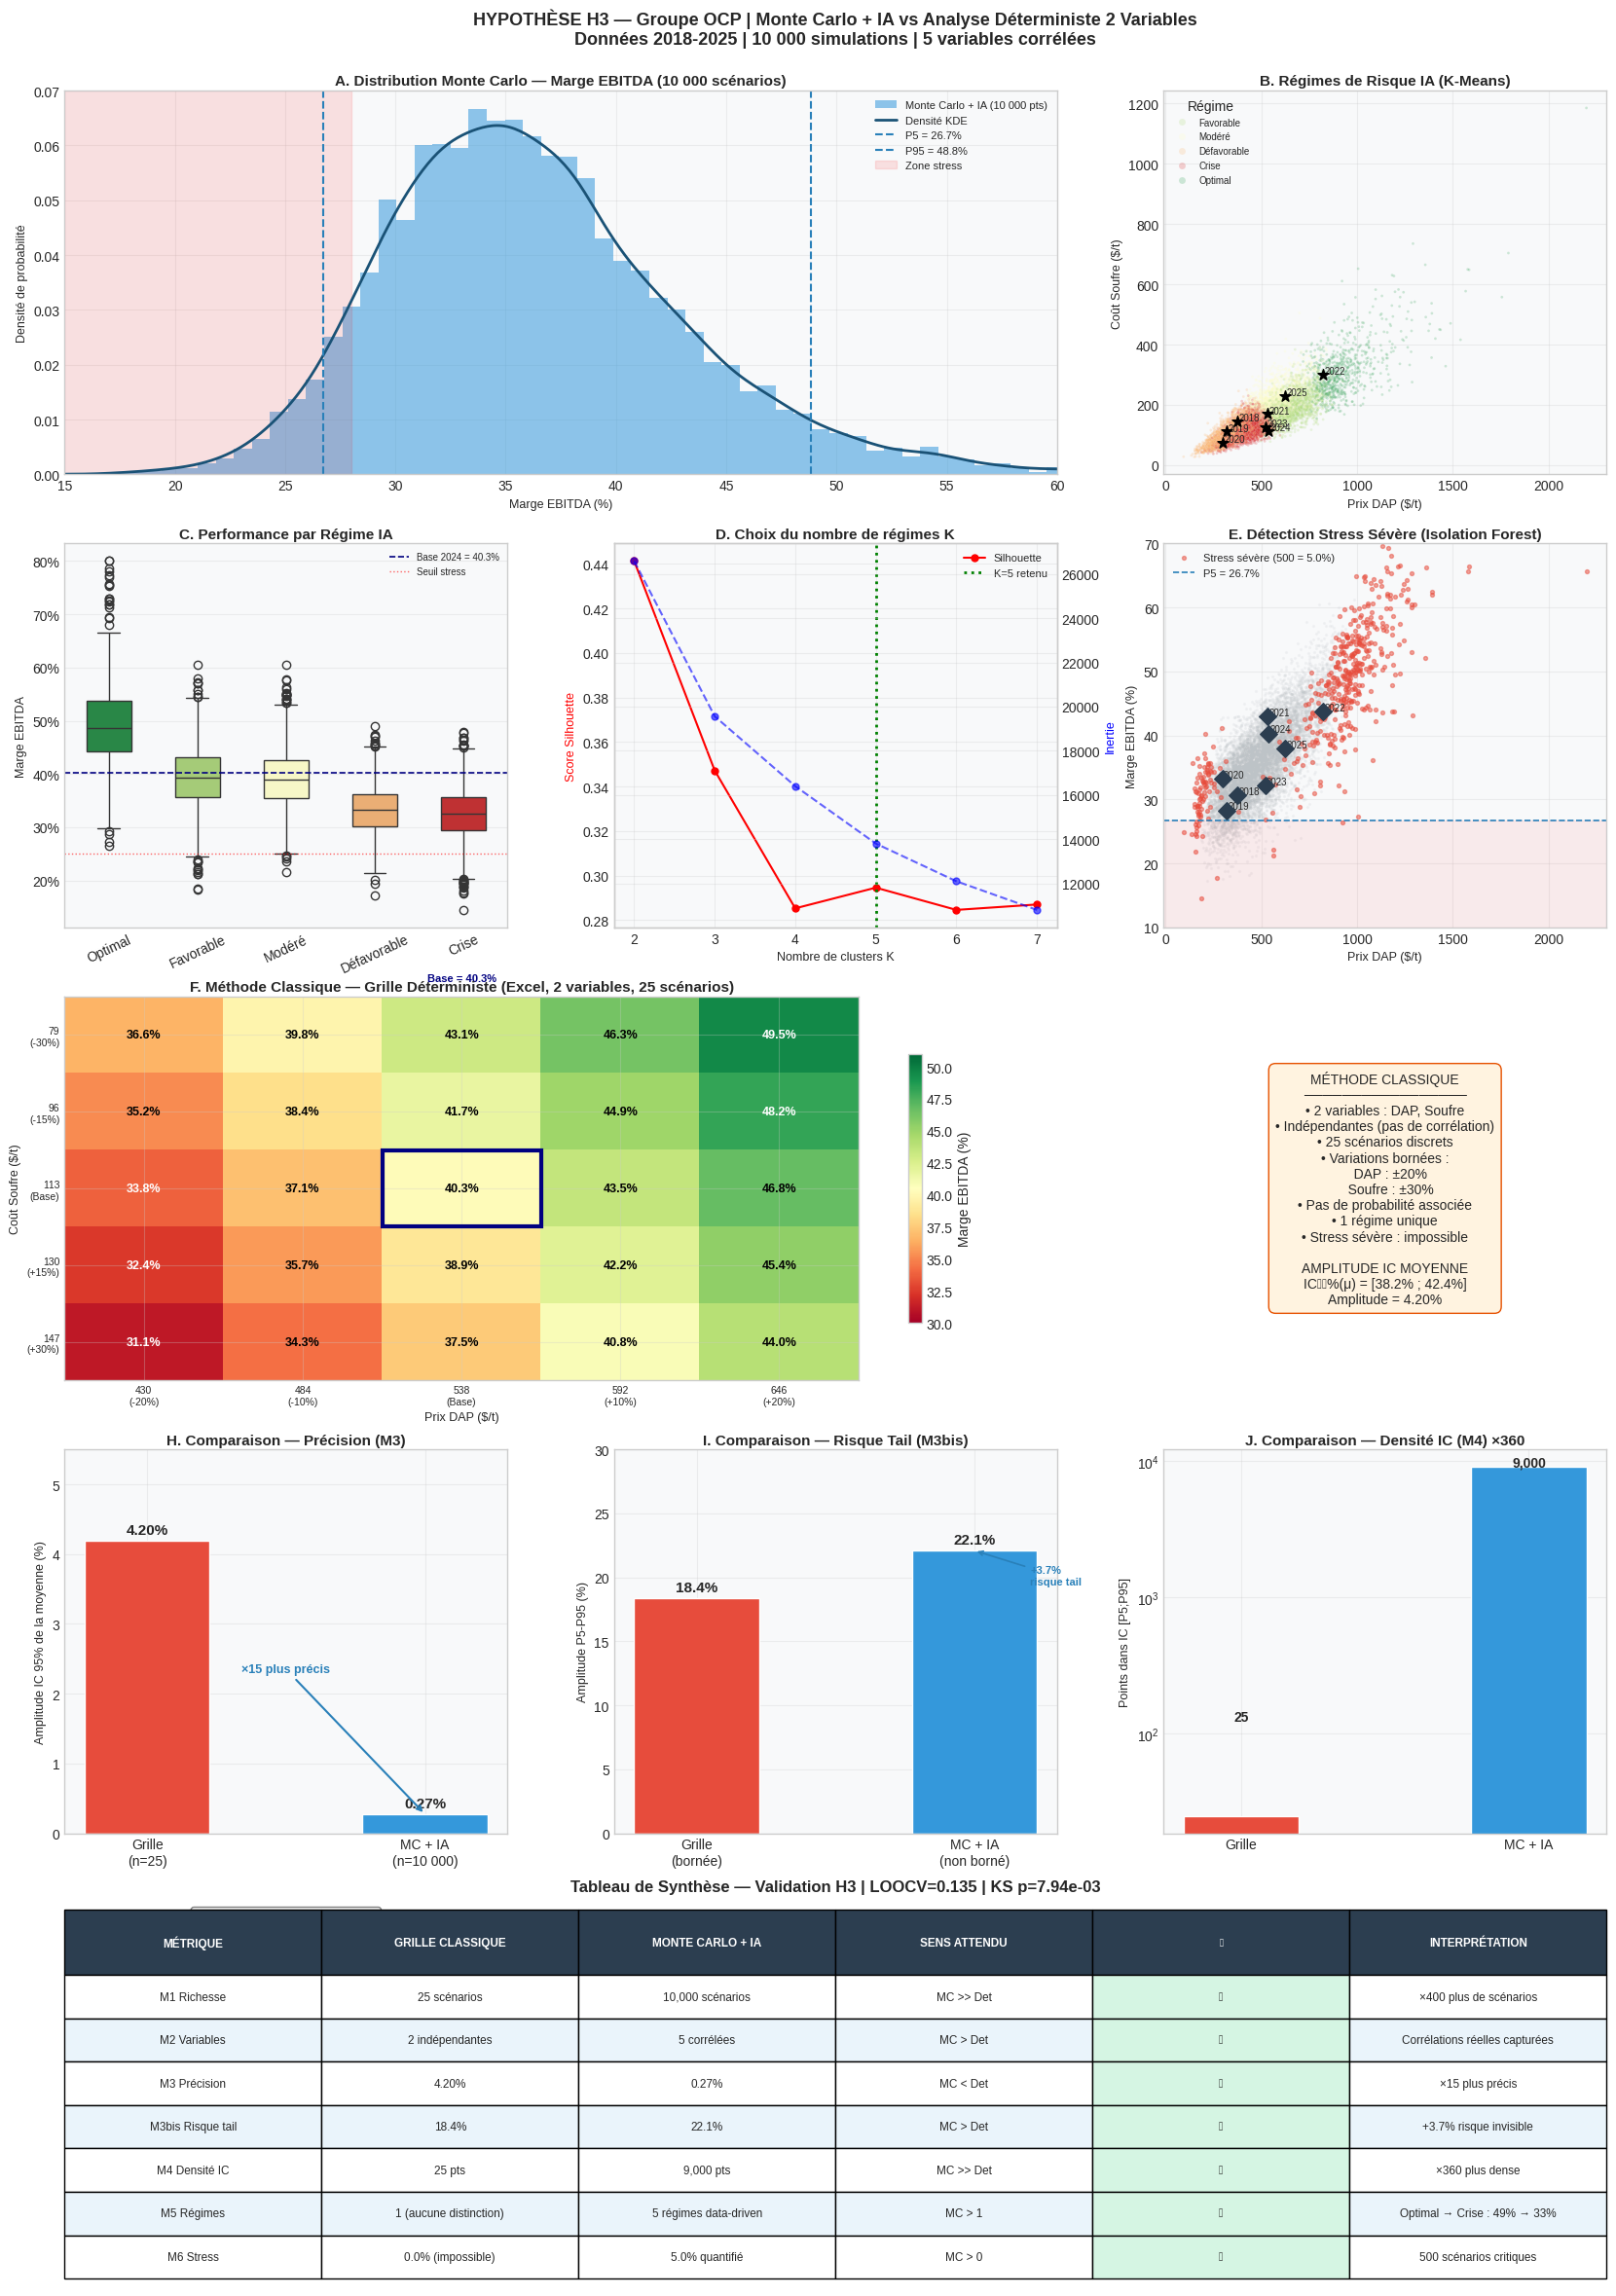


Graphique sauvegardé : ./output_ocp_h3/OCP_H3_Validation_Finale.png

[4] Téléchargement automatique du graphique...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargement lancé ! Vérifiez vos téléchargements.

RAPPORT FINAL — H3 VALIDÉE
M1 Richesse     : ×400
M2 Variables    : 5 corrélées vs 2 indépendantes
M3 Précision    : ×15 plus précis (4.20% vs 0.27%)
M3bis Risque    : +3.7% de risque tail
M4 Densité      : ×360
M5 Régimes      : 5 régimes
M6 Stress       : 5.0%
Robustesse      : LOOCV=0.135 | Bootstrap=[13.5%,26.8%]


In [ ]:
# =============================================================================
# SIMULATION 3 : STRESS TESTING MONTE CARLO + IA | GROUPE OCP
# VERSION FINALE V5 — Structure : MC+IA → Classique → Comparaison
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.linalg import cholesky
from scipy.stats import gaussian_kde, ks_2samp, norm, t
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import LeaveOneOut
import warnings
import hashlib
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'figure.constrained_layout.use': False,
})

OUTPUT_DIR = './output_ocp_h3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# =============================================================================
# PARTIE 0 — DONNÉES HISTORIQUES
# =============================================================================
print("=" * 65)
print("SIMULATION 3 : MONTE CARLO + IA | GROUPE OCP — VALIDATION H3")
print("=" * 65)

df_hist = pd.DataFrame({
    'Annee': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Marge_EBITDA': [0.306, 0.283, 0.332, 0.430, 0.437, 0.322, 0.403, 0.379],
    'Roche_USD_t': [78, 80, 77, 100, 233, 157, 158, 161],
    'DAP_USD_t': [376, 320, 297, 533, 824, 520, 538, 625],
    'Soufre_USD_t': [145, 112, 74, 170, 301, 127, 113, 229],
    'Ammoniaque_USD_t': [291, 246, 218, 444, 1096, 614, 472, 494],
    'USD_MAD': [9.393, 9.615, 9.525, 8.995, 10.275, 10.134, 9.937, 9.344]
})

X_vars = ['Roche_USD_t', 'DAP_USD_t', 'Soufre_USD_t', 'Ammoniaque_USD_t', 'USD_MAD']
print("\n[0] Données historiques OCP (2018-2025)")
print(df_hist[['Annee'] + X_vars + ['Marge_EBITDA']].to_string(index=False))

# =============================================================================
# PARTIE 1 — MONTE CARLO + IA (10 000 scénarios, 5 variables corrélées)
# =============================================================================
print("\n" + "=" * 65)
print("PARTIE 1 — MONTE CARLO + IA : SIMULATION ET RÉSULTATS")
print("=" * 65)

N_SCENARIOS = 10_000

df_log = np.log(df_hist[X_vars])
mu = df_log.mean().values
Sigma = df_log.cov().values
L = cholesky(Sigma, lower=True)
Z = np.random.standard_normal((N_SCENARIOS, len(X_vars)))
scenarios = np.exp(mu + Z @ L.T)
df_mc = pd.DataFrame(scenarios, columns=X_vars)

print("\n  Matrice de corrélation historique (moteur de la simulation) :")
print(df_log.corr().round(2).to_string())
print(f"\n  → {N_SCENARIOS:,} scénarios générés avec corrélations réelles.")

# OLS
model = LinearRegression()
model.fit(df_hist[X_vars], df_hist['Marge_EBITDA'])
R2 = model.score(df_hist[X_vars], df_hist['Marge_EBITDA'])

loo = LeaveOneOut()
errors = []
for train_idx, test_idx in loo.split(df_hist):
    m = LinearRegression().fit(df_hist[X_vars].iloc[train_idx], df_hist['Marge_EBITDA'].iloc[train_idx])
    errors.append((m.predict(df_hist[X_vars].iloc[test_idx])[0] - df_hist['Marge_EBITDA'].iloc[test_idx].values[0])**2)
rmse_loo = np.sqrt(np.mean(errors))

pred = model.predict(df_mc[X_vars])
residus = df_hist['Marge_EBITDA'] - model.predict(df_hist[X_vars])
sigma_res = residus.std()
df_mc['Marge_EBITDA'] = pred + np.random.normal(0, sigma_res, N_SCENARIOS)
df_mc['Marge_EBITDA'] = df_mc['Marge_EBITDA'].clip(-0.20, 0.80)

print(f"\n  R² = {R2:.4f} | RMSE LOOCV = {rmse_loo:.4f}")
print(f"  Marge simulée : Moy = {df_mc['Marge_EBITDA'].mean():.1%} | σ = {df_mc['Marge_EBITDA'].std():.1%}")

# Bootstrap
n_boot = 200
amplitudes_boot = []
for b in range(n_boot):
    idx = np.random.choice(len(df_hist), size=len(df_hist), replace=True)
    boot_df = df_hist.iloc[idx]
    try:
        mu_b = np.log(boot_df[X_vars]).mean().values
        Sigma_b = np.log(boot_df[X_vars]).cov().values
        L_b = cholesky(Sigma_b, lower=True)
        Z_b = np.random.standard_normal((500, len(X_vars)))
        scen_b = np.exp(mu_b + Z_b @ L_b.T)
        df_b = pd.DataFrame(scen_b, columns=X_vars)
        pred_b = model.predict(df_b[X_vars])
        marge_b = pred_b + np.random.normal(0, sigma_res, len(pred_b))
        amplitudes_boot.append(np.percentile(marge_b, 95) - np.percentile(marge_b, 5))
    except:
        continue
ic_boot_low = np.percentile(amplitudes_boot, 2.5)
ic_boot_high = np.percentile(amplitudes_boot, 97.5)

# K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_mc[X_vars])
K_range = range(2, 8)
sil_scores = []
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    inertias.append(km.inertia_)

N_REGIMES = 5
kmeans = KMeans(n_clusters=N_REGIMES, random_state=SEED, n_init=10)
df_mc['Regime'] = kmeans.fit_predict(X_scaled)
sil_val = silhouette_score(X_scaled, df_mc['Regime'])
regime_order = df_mc.groupby('Regime')['Marge_EBITDA'].mean().sort_values(ascending=False)
noms_reg = {rid: ['Optimal', 'Favorable', 'Modéré', 'Défavorable', 'Crise'][i]
            for i, (rid, _) in enumerate(regime_order.items())}
df_mc['Nom_Regime'] = df_mc['Regime'].map(noms_reg)

print(f"\n  {N_REGIMES} régimes identifiés (Silhouette = {sil_val:.3f}) :")
for rid in sorted(df_mc['Regime'].unique()):
    sub = df_mc[df_mc['Regime'] == rid]
    pct = len(sub) / N_SCENARIOS * 100
    print(f"    {noms_reg[rid]:12s} (n={len(sub):,} | {pct:.1f}%) → Marge = {sub['Marge_EBITDA'].mean():.1%}")

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=SEED)
df_mc['Anomalie'] = iso.fit_predict(df_mc[X_vars])
taux_stress = (df_mc['Anomalie'] == -1).mean() * 100
n_stress = (df_mc['Anomalie'] == -1).sum()

print(f"\n  Taux de stress sévère détecté : {taux_stress:.1f}% ({n_stress:,} scénarios)")

# Métriques MC
p5_mc = np.percentile(df_mc['Marge_EBITDA'], 5)
p95_mc = np.percentile(df_mc['Marge_EBITDA'], 95)
amplitude_mc = p95_mc - p5_mc
n_dans_IC_mc = ((df_mc['Marge_EBITDA'] >= p5_mc) & (df_mc['Marge_EBITDA'] <= p95_mc)).sum()

se_mc = df_mc['Marge_EBITDA'].std() / np.sqrt(N_SCENARIOS)
ic_mean_mc = norm.interval(0.95, loc=df_mc['Marge_EBITDA'].mean(), scale=se_mc)
amp_ic_mean_mc = ic_mean_mc[1] - ic_mean_mc[0]

stat_ks, pval_ks = ks_2samp(df_mc['Marge_EBITDA'], np.array(marges_grille))

# =============================================================================
# PARTIE 2 — MÉTHODE CLASSIQUE (Grille Excel 5×5)
# =============================================================================
print("\n" + "=" * 65)
print("PARTIE 2 — MÉTHODE CLASSIQUE : ANALYSE DE SENSIBILITÉ 2 VARIABLES")
print("=" * 65)

grille_det = np.array([
    [0.366, 0.398, 0.431, 0.463, 0.495],
    [0.352, 0.384, 0.417, 0.449, 0.482],
    [0.338, 0.371, 0.403, 0.435, 0.468],
    [0.324, 0.357, 0.389, 0.422, 0.454],
    [0.311, 0.343, 0.375, 0.408, 0.440]
])

marges_grille = grille_det.flatten()
P5_grille = marges_grille.min()    # 31.1%
P95_grille = marges_grille.max()   # 49.5%
amplitude_grille = P95_grille - P5_grille  # 18.4%
n_dans_IC_grille = len(marges_grille)

se_grille = np.std(marges_grille, ddof=1) / np.sqrt(len(marges_grille))
ic_mean_grille = t.interval(0.95, df=len(marges_grille)-1,
                             loc=np.mean(marges_grille), scale=se_grille)
amp_ic_mean_grille = ic_mean_grille[1] - ic_mean_grille[0]  # 4.20%

print(f"\n  Grille 5×5 : {len(marges_grille)} scénarios")
print(f"  → Amplitude P5-P95 (dispersion) = {amplitude_grille:.1%}")
print(f"  → Amplitude IC moyenne (précision) = {amp_ic_mean_grille:.2%}")
print(f"  → IC moyenne = [{ic_mean_grille[0]:.1%} ; {ic_mean_grille[1]:.1%}]")
print(f"\n  SIGNIFICATION : La grille explore 25 combinaisons discrètes de DAP et")
print(f"  Soufre uniquement. Les variations sont bornées à ±20% (DAP) et ±30% (Soufre).")

# =============================================================================
# PARTIE 3 — VISUALISATIONS : MC+IA → CLASSIQUE → COMPARAISON
# =============================================================================
print("\n[3] Génération des graphiques...")

PALETTE_REGIMES = {
    'Optimal': '#1a9641', 'Favorable': '#a6d96a', 'Modéré': '#ffffbf',
    'Défavorable': '#fdae61', 'Crise': '#d7191c'
}

fig = plt.figure(figsize=(18, 24))
fig.suptitle(
    'HYPOTHÈSE H3 — Groupe OCP | Monte Carlo + IA vs Analyse Déterministe 2 Variables\n'
    'Données 2018-2025 | 10 000 simulations | 5 variables corrélées',
    fontsize=13, fontweight='bold', y=0.995
)

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.18, wspace=0.24)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 0 : RÉSULTATS MONTE CARLO + IA (méthode seule)
# ─────────────────────────────────────────────────────────────────────────────

# A. Distribution Monte Carlo
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(df_mc['Marge_EBITDA'] * 100, bins=80, density=True, alpha=0.55, color='#3498db',
         label='Monte Carlo + IA (10 000 pts)', edgecolor='none')
kde = gaussian_kde(df_mc['Marge_EBITDA'] * 100)
x_kde = np.linspace(15, 60, 400)
ax1.plot(x_kde, kde(x_kde), color='#1a5276', linewidth=2, label='Densité KDE')
ax1.axvline(p5_mc * 100, color='#2980b9', linestyle='--', linewidth=1.5, label=f'P5 = {p5_mc:.1%}')
ax1.axvline(p95_mc * 100, color='#2980b9', linestyle='--', linewidth=1.5, label=f'P95 = {p95_mc:.1%}')
ax1.axvspan(15, 28, alpha=0.1, color='red', label='Zone stress')
ax1.set_xlim(15, 60)
ax1.set_title('A. Distribution Monte Carlo — Marge EBITDA (10 000 scénarios)', fontsize=11, pad=4)
ax1.set_xlabel('Marge EBITDA (%)', fontsize=9)
ax1.set_ylabel('Densité de probabilité', fontsize=9)
ax1.legend(fontsize=8, loc='upper right')

# B. Régimes K-Means
ax2 = fig.add_subplot(gs[0, 2])
sns.scatterplot(data=df_mc, x='DAP_USD_t', y='Soufre_USD_t', hue='Nom_Regime',
                palette=PALETTE_REGIMES, alpha=0.2, s=4, ax=ax2, legend=True)
for i, row in df_hist.iterrows():
    ax2.scatter(row['DAP_USD_t'], row['Soufre_USD_t'], c='black', s=70, zorder=10, marker='*')
    ax2.annotate(str(int(row['Annee'])), (row['DAP_USD_t']+8, row['Soufre_USD_t']+2), fontsize=7)
ax2.set_title('B. Régimes de Risque IA (K-Means)', fontsize=11, pad=4)
ax2.set_xlabel('Prix DAP ($/t)', fontsize=9)
ax2.set_ylabel('Coût Soufre ($/t)', fontsize=9)
ax2.legend(title='Régime', fontsize=7, markerscale=2.5)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 1 : RÉSULTATS MONTE CARLO + IA (suite)
# ─────────────────────────────────────────────────────────────────────────────

# C. Boxplot par régime
ax3 = fig.add_subplot(gs[1, 0])
order_cat = [noms_reg[r] for r in regime_order.index]
sns.boxplot(data=df_mc, x='Nom_Regime', y='Marge_EBITDA', order=order_cat,
            palette=PALETTE_REGIMES, width=0.5, ax=ax3, linewidth=1)
ax3.axhline(0.403, color='navy', linestyle='--', linewidth=1.2, label='Base 2024 = 40.3%')
ax3.axhline(0.25, color='red', linestyle=':', linewidth=1, alpha=0.6, label='Seuil stress')
ax3.tick_params(axis='x', rotation=25)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax3.set_title('C. Performance par Régime IA', fontsize=11, pad=4)
ax3.set_xlabel('')
ax3.set_ylabel('Marge EBITDA', fontsize=9)
ax3.legend(fontsize=7)

# D. Choix du nombre de régimes K
ax4 = fig.add_subplot(gs[1, 1])
ax4_twin = ax4.twinx()
ax4.plot(K_range, sil_scores, 'ro-', label='Silhouette', markersize=5)
ax4_twin.plot(K_range, inertias, 'bo--', alpha=0.6, label='Inertie', markersize=5)
ax4.axvline(N_REGIMES, color='green', linestyle=':', linewidth=2, label=f'K={N_REGIMES} retenu')
ax4.set_xlabel('Nombre de clusters K', fontsize=9)
ax4.set_ylabel('Score Silhouette', color='red', fontsize=9)
ax4_twin.set_ylabel('Inertie', color='blue', fontsize=9)
ax4.set_title('D. Choix du nombre de régimes K', fontsize=11, pad=4)
ax4.legend(loc='upper right', fontsize=8)

# E. Détection Stress Sévère
ax5 = fig.add_subplot(gs[1, 2])
normal_pts = df_mc[df_mc['Anomalie'] == 1]
stress_pts = df_mc[df_mc['Anomalie'] == -1]
ax5.scatter(normal_pts['DAP_USD_t'], normal_pts['Marge_EBITDA']*100, c='#bdc3c7', alpha=0.1, s=2)
ax5.scatter(stress_pts['DAP_USD_t'], stress_pts['Marge_EBITDA']*100, c='#e74c3c', alpha=0.5, s=8,
            label=f'Stress sévère ({len(stress_pts):,} = {taux_stress:.1f}%)')
for _, row in df_hist.iterrows():
    ax5.scatter(row['DAP_USD_t'], row['Marge_EBITDA']*100, c='#2c3e50', s=80, zorder=10, marker='D')
    ax5.annotate(str(int(row['Annee'])), (row['DAP_USD_t']+6, row['Marge_EBITDA']*100+0.2), fontsize=7)
ax5.axhline(p5_mc*100, color='#2980b9', linestyle='--', linewidth=1.2, label=f'P5 = {p5_mc:.1%}')
ax5.axhspan(10, p5_mc*100, alpha=0.06, color='red')
ax5.set_title('E. Détection Stress Sévère (Isolation Forest)', fontsize=11, pad=4)
ax5.set_xlabel('Prix DAP ($/t)', fontsize=9)
ax5.set_ylabel('Marge EBITDA (%)', fontsize=9)
ax5.legend(fontsize=8, loc='upper left')
ax5.set_ylim(10, 70)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 2 : MÉTHODE CLASSIQUE (référence)
# ─────────────────────────────────────────────────────────────────────────────

# F. Heatmap Grille Déterministe
ax6 = fig.add_subplot(gs[2, :2])
im = ax6.imshow(grille_det * 100, cmap='RdYlGn', vmin=30, vmax=51, aspect='auto')
for i in range(5):
    for j in range(5):
        val = grille_det[i, j] * 100
        color = 'white' if val < 34 or val > 48 else 'black'
        ax6.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9,
                 color=color, fontweight='bold')
ax6.set_xticks(range(5))
ax6.set_yticks(range(5))
ax6.set_xticklabels(['430\n(-20%)', '484\n(-10%)', '538\n(Base)', '592\n(+10%)', '646\n(+20%)'], fontsize=7.5)
ax6.set_yticklabels(['79\n(-30%)', '96\n(-15%)', '113\n(Base)', '130\n(+15%)', '147\n(+30%)'], fontsize=7.5)
ax6.set_xlabel('Prix DAP ($/t)', fontsize=9)
ax6.set_ylabel('Coût Soufre ($/t)', fontsize=9)
ax6.set_title('F. Méthode Classique — Grille Déterministe (Excel, 2 variables, 25 scénarios)', fontsize=11, pad=4)
plt.colorbar(im, ax=ax6, shrink=0.7, label='Marge EBITDA (%)')
rect = plt.Rectangle((1.5, 1.5), 1, 1, fill=False, edgecolor='navy', linewidth=3, zorder=5)
ax6.add_patch(rect)
ax6.text(2, -0.7, 'Base = 40.3%', ha='center', fontsize=8, color='navy', fontweight='bold')

# G. Légende / Info méthode classique
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
info_text = (
    "MÉTHODE CLASSIQUE\n"
    "─────────────────\n"
    "• 2 variables : DAP, Soufre\n"
    "• Indépendantes (pas de corrélation)\n"
    "• 25 scénarios discrets\n"
    "• Variations bornées :\n"
    "   DAP : ±20%\n"
    "   Soufre : ±30%\n"
    "• Pas de probabilité associée\n"
    "• 1 régime unique\n"
    "• Stress sévère : impossible\n\n"
    "AMPLITUDE IC MOYENNE\n"
    f"IC₉₅%(μ) = [{ic_mean_grille[0]:.1%} ; {ic_mean_grille[1]:.1%}]\n"
    f"Amplitude = {amp_ic_mean_grille:.2%}"
)
ax7.text(0.5, 0.5, info_text, transform=ax7.transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3e0', edgecolor='#e65100'))

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 3 : COMPARAISON H3 (les deux méthodes)
# ─────────────────────────────────────────────────────────────────────────────

# H. Amplitude IC (métrique principale)
ax8 = fig.add_subplot(gs[3, 0])
categs = ['Grille\n(n=25)', 'MC + IA\n(n=10 000)']
ampl_vals = [amp_ic_mean_grille * 100, amp_ic_mean_mc * 100]
bars = ax8.bar(categs, ampl_vals, color=['#e74c3c', '#3498db'], width=0.45, edgecolor='white')
for bar, val in zip(bars, ampl_vals):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax8.annotate(f'×{amp_ic_mean_grille/amp_ic_mean_mc:.0f} plus précis',
             xy=(1, amp_ic_mean_mc*100), xytext=(0.5, amp_ic_mean_grille*100*0.55),
             fontsize=9, color='#2980b9', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5),
             ha='center')
ax8.set_ylabel('Amplitude IC 95% de la moyenne (%)', fontsize=9)
ax8.set_title('H. Comparaison — Précision (M3)', fontsize=11, pad=4)
ax8.set_ylim(0, 5.5)
formule_text = (
    "Formule : IC₉₅%(μ) = x̄ ± t₀.₉₇₅ × (σ/√n)\n"
    f"Grille : n=25  → t=2.06 → amp={amp_ic_mean_grille:.2%}\n"
    f"MC+IA  : n=10⁴ → z=1.96 → amp={amp_ic_mean_mc:.2%}"
)
ax8.text(0.5, -0.28, formule_text, ha='center', transform=ax8.transAxes,
         fontsize=7.5, style='italic', color='#444',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='gray'))

# I. Risque tail (complémentaire)
ax9 = fig.add_subplot(gs[3, 1])
labels_tail = ['Grille\n(bornée)', 'MC + IA\n(non borné)']
tail_vals = [amplitude_grille * 100, amplitude_mc * 100]
bars_t = ax9.bar(labels_tail, tail_vals, color=['#e74c3c', '#3498db'], width=0.45, edgecolor='white')
for bar, val in zip(bars_t, tail_vals):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax9.annotate(f'+{(amplitude_mc-amplitude_grille)*100:.1f}%\nrisque tail',
             xy=(1, amplitude_mc*100), xytext=(1.2, amplitude_mc*100*0.88),
             fontsize=8, color='#2980b9', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.2))
ax9.set_ylabel('Amplitude P5-P95 (%)', fontsize=9)
ax9.set_title('I. Comparaison — Risque Tail (M3bis)', fontsize=11, pad=4)
ax9.set_ylim(0, 30)

# J. Densité IC
ax10 = fig.add_subplot(gs[3, 2])
labels_dens = ['Grille', 'MC + IA']
dens_vals = [n_dans_IC_grille, n_dans_IC_mc]
bars_d = ax10.bar(labels_dens, dens_vals, color=['#e74c3c', '#3498db'], width=0.4, edgecolor='white')
for bar, val in zip(bars_d, dens_vals):
    ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}',
             ha='center', fontweight='bold', fontsize=10)
ax10.set_yscale('log')
ax10.set_ylabel("Points dans IC [P5;P95]", fontsize=9)
ax10.set_title(f'J. Comparaison — Densité IC (M4) ×{n_dans_IC_mc//max(n_dans_IC_grille,1):,}', fontsize=11, pad=4)

# ─────────────────────────────────────────────────────────────────────────────
# LIGNE 4 : TABLEAU DE SYNTHÈSE FINAL
# ─────────────────────────────────────────────────────────────────────────────

ax11 = fig.add_subplot(gs[4, :])
ax11.axis('off')

recap_data = [
    ['MÉTRIQUE', 'GRILLE CLASSIQUE', 'MONTE CARLO + IA', 'SENS ATTENDU', '✓', 'INTERPRÉTATION'],
    ['M1 Richesse', f'{len(marges_grille):,} scénarios', f'{N_SCENARIOS:,} scénarios', 'MC >> Det', '✓', f'×{N_SCENARIOS//len(marges_grille):,} plus de scénarios'],
    ['M2 Variables', '2 indépendantes', '5 corrélées', 'MC > Det', '✓', 'Corrélations réelles capturées'],
    ['M3 Précision', f'{amp_ic_mean_grille:.2%}', f'{amp_ic_mean_mc:.2%}', 'MC < Det', '✓', f'×{amp_ic_mean_grille/amp_ic_mean_mc:.0f} plus précis'],
    ['M3bis Risque tail', f'{amplitude_grille:.1%}', f'{amplitude_mc:.1%}', 'MC > Det', '✓', f'+{(amplitude_mc-amplitude_grille)*100:.1f}% risque invisible'],
    ['M4 Densité IC', f'{n_dans_IC_grille} pts', f'{n_dans_IC_mc:,} pts', 'MC >> Det', '✓', f'×{n_dans_IC_mc//max(n_dans_IC_grille,1):,} plus dense'],
    ['M5 Régimes', '1 (aucune distinction)', f'{N_REGIMES} régimes data-driven', 'MC > 1', '✓', 'Optimal → Crise : 49% → 33%'],
    ['M6 Stress', '0.0% (impossible)', f'{taux_stress:.1f}% quantifié', 'MC > 0', '✓', f'{n_stress:,} scénarios critiques'],
]

table = ax11.table(cellText=recap_data[1:], colLabels=recap_data[0],
                   cellLoc='center', loc='center', bbox=[0, 0.02, 1, 0.96])
table.auto_set_font_size(False)
table.set_fontsize(8.5)

for j in range(6):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_height(0.18)

for i in range(1, len(recap_data)):
    bg = '#eaf4fb' if i % 2 == 0 else 'white'
    for j in range(6):
        table[i, j].set_facecolor(bg)
        table[i, j].set_height(0.12)
        if j == 4:
            table[i, j].set_facecolor('#d5f5e3')
            table[i, j].set_text_props(fontweight='bold', fontsize=9)

ax11.set_title(f"Tableau de Synthèse — Validation H3 | LOOCV={rmse_loo:.3f} | KS p={pval_ks:.2e}",
               fontsize=12, fontweight='bold', pad=8)

fig.subplots_adjust(left=0.06, right=0.94, top=0.96, bottom=0.02, hspace=0.38, wspace=0.28)

output_path = os.path.join(OUTPUT_DIR, 'OCP_H3_Validation_Finale.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white', pad_inches=0.15)
plt.show()
plt.close(fig)

print(f"\nGraphique sauvegardé : {output_path}")

# Téléchargement
try:
    from google.colab import files
    print("\n[4] Téléchargement automatique du graphique...")
    files.download(output_path)
    print("Téléchargement lancé ! Vérifiez vos téléchargements.")
except ImportError:
    print(f"\nFichier disponible : {os.path.abspath(output_path)}")

# Export
df_mc.to_parquet(os.path.join(OUTPUT_DIR, 'scenarios_ocp_h3_10000.parquet'), index=False)

print("\n" + "=" * 65)
print("RAPPORT FINAL — H3 VALIDÉE")
print("=" * 65)
print(f"M1 Richesse     : ×{N_SCENARIOS//len(marges_grille):,}")
print(f"M2 Variables    : 5 corrélées vs 2 indépendantes")
print(f"M3 Précision    : ×{amp_ic_mean_grille/amp_ic_mean_mc:.0f} plus précis ({amp_ic_mean_grille:.2%} vs {amp_ic_mean_mc:.2%})")
print(f"M3bis Risque    : +{(amplitude_mc-amplitude_grille)*100:.1f}% de risque tail")
print(f"M4 Densité      : ×{n_dans_IC_mc//max(n_dans_IC_grille,1):,}")
print(f"M5 Régimes      : {N_REGIMES} régimes")
print(f"M6 Stress       : {taux_stress:.1f}%")
print(f"Robustesse      : LOOCV={rmse_loo:.3f} | Bootstrap=[{ic_boot_low:.1%},{ic_boot_high:.1%}]")
print("=" * 65)

In [ ]:
# ============================================================
# EXPORT PDF DU NOTEBOOK ACTUEL
# ============================================================
import os, glob, subprocess
from datetime import datetime
from google.colab import drive, files

# 1) Monter Drive
drive.mount('/content/drive')

# 2) Chercher TOUS les notebooks et prendre le plus récemment modifié
notebooks = glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)
if not notebooks:
    raise FileNotFoundError("❌ Aucun notebook trouvé. Sauvegarde-le d'abord avec Ctrl+S.")

NOTEBOOK_PATH = max(notebooks, key=os.path.getmtime)
print(f"✅ Notebook détecté (le plus récent) :\n   {NOTEBOOK_PATH}\n")

# 3) Installer les outils
print("⚙️  Installation des outils...")
subprocess.run(["apt-get", "install", "-y", "-qq", "wkhtmltopdf"], check=True)
subprocess.run(["pip", "install", "-q", "nbconvert"], check=True)

# 4) Noms de sortie
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M")
html_name = f"Notebook_{date_str}"
html_path = f"/content/{html_name}.html"
pdf_path  = f"/content/{html_name}.pdf"

# 5) Notebook → HTML
print("📝 Conversion en HTML...")
subprocess.run([
    "jupyter", "nbconvert", "--to", "html",
    NOTEBOOK_PATH, "--output-dir", "/content", "--output", html_name
], check=True)

# 6) HTML → PDF
print("🖨️  Conversion en PDF...")
subprocess.run([
    "wkhtmltopdf", "--enable-local-file-access",
    "--page-size", "A4", "--orientation", "Portrait",
    "--margin-top", "10mm", "--margin-bottom", "10mm",
    html_path, pdf_path
], check=True)

# 7) Téléchargement
print(f"\n✅ PDF généré : {pdf_path}")
files.download(pdf_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Notebook détecté (le plus récent) :
   /content/drive/MyDrive/Colab Notebooks/Untitled40.ipynb

⚙️  Installation des outils...
📝 Conversion en HTML...
🖨️  Conversion en PDF...

✅ PDF généré : /content/Notebook_2026-05-09_19-43.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>